In [1]:
import geopandas as gpd
import numpy as np
import contextily as cx
import rasterio
from rasterio.mask import mask
from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union, polygonize
import osmnx as ox
import neatnet
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [105]:
# Parameters Global
RUN_EXPORT_street = False
RUN_EXPORT_buildings = False
RUN_EXPORT_blocks = False
RUN_EXPORT_blockimagery = False

# Choose the city prefix you want to analyze
selected_city_key = 'ath'  # Switch to 'ath' or 'barc' etc.

# Select Imagery provider 
from xyzservices import TileProvider
google_satellite = TileProvider(
    name="Google Satellite",
    url="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
    attribution="Google",
    max_zoom=20
)

ESRI_imagery = cx.providers.Esri.WorldImagery

Imagery = google_satellite

In [3]:

dist = 2800

from types import SimpleNamespace

# Define all cities in one namespace
cities = SimpleNamespace(
    barc=SimpleNamespace(name="Barcelona", coord=(41.381426, 2.173053), crs=25831),
    ath=SimpleNamespace(name="Athens", coord=(37.989702027509686, 23.738142824327344), crs=2100),
    tyo=SimpleNamespace(name="Tokyo", coord=(35.702950, 139.769753), crs=3099),
    lbrgh=SimpleNamespace(name="Loughborough", coord=(52.767225, -1.220030), crs=27700),
    mk=SimpleNamespace(name="Milton Keynes", coord=(52.0406, -0.7594), crs=27700),
    ldn=SimpleNamespace(name="London_Camden", coord=(51.543001, -0.183654), crs=27700),  # NEW
    # Additions
    nyc=SimpleNamespace(name="New_York_Manhattan", coord=(40.7580, -73.9855), crs=2263),
    paris=SimpleNamespace(name="Paris", coord=(48.8566, 2.3522), crs=2154),
    ams=SimpleNamespace(name="Amsterdam", coord=(52.3676, 4.9041), crs=28992),
    ven=SimpleNamespace(name="Venice", coord=(45.4408, 12.3155), crs=32633),
    bra=SimpleNamespace(name="Brasilia", coord=(-15.7939, -47.8828), crs=31983),
    marr=SimpleNamespace(name="Marrakech_Medina", coord=(31.6295, -7.9811), crs=26191),
    # Colouring Cities / open-data-aligned additions
    dres=SimpleNamespace(name="Dresden", coord=(51.0504, 13.7373), crs=25833),
    sthlm=SimpleNamespace(name="Stockholm", coord=(59.3293, 18.0686), crs=3006),
    melb=SimpleNamespace(name="Melbourne", coord=(-37.8136, 144.9631), crs=7855),
    mtl=SimpleNamespace(name="Montreal", coord=(45.5017, -73.5673), crs=2950),
    jak=SimpleNamespace(name="Jakarta", coord=(-6.2000, 106.8167), crs=23845)
)



# Create a reference to the selected city
city = getattr(cities, selected_city_key)
print (city.name)

Athens


In [84]:
# Download OSM street network
center_point = city.coord
custom_filter = (
    '["highway"~"motorway|trunk|primary|secondary|tertiary|footway|pedestrian|path|steps"]'
)
custom_filter1 = '["highway"~"motorway|trunk|primary|secondary|tertiary|unclassified|residential|service|pedestrian|steps|living_street"]'	

osm_graph=ox.graph.graph_from_point(
    center_point, 
    dist, 
    dist_type='bbox', 
    network_type= 'drive', # "all_public", "all", "bike", "drive", "drive_service", "walk", "pedestrian"
    simplify=True, 
    retain_all=True, 
    truncate_by_edge=True, 
    custom_filter=custom_filter1)

print(f"Downloaded street network for {center_point}")


Downloaded street network for (37.989702027509686, 23.738142824327344)


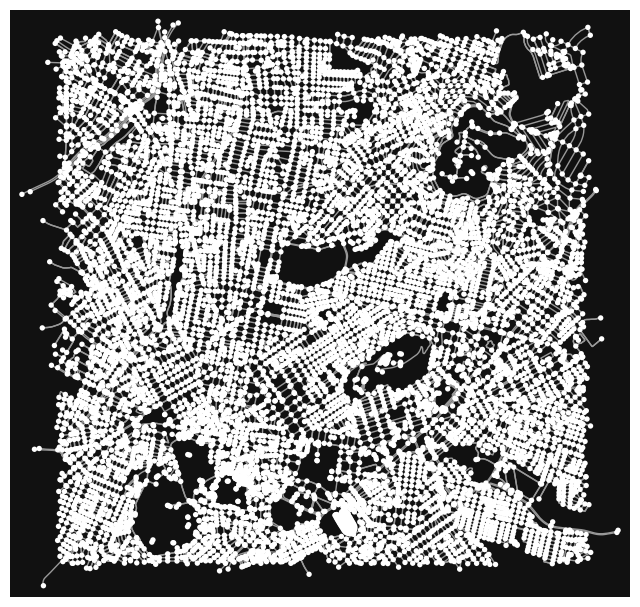

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [85]:
# Plot street network 
ox.plot_graph(osm_graph)

In [86]:
# you already built `osm_graph` above
G = osm_graph

# Convert to GeoDataFrames
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

# Ensure WGS84 (GeoJSON expects lon/lat)
nodes_gdf = nodes_gdf.to_crs(epsg=4326)
edges_gdf = edges_gdf.to_crs(epsg=4326)

if RUN_EXPORT_street: 
    #Write out as GeoJSON (separate files: points + lines)
    nodes_gdf.to_file("street_nodes.geojson", driver="GeoJSON")
    edges_gdf.to_file("street_edges.geojson", driver="GeoJSON")
    
    print("Saved GeoJSON: street_nodes.geojson and street_edges.geojson")

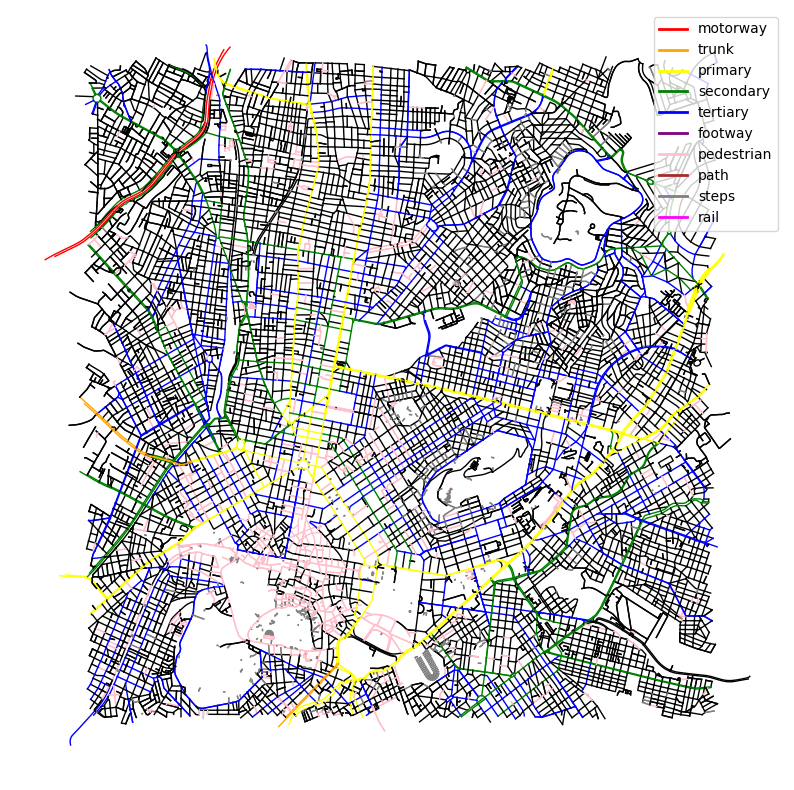

In [87]:
# Road Analysis OSM

road_colors = {
    'motorway': 'red',
    'trunk': 'orange',
    'primary': 'yellow',
    'secondary': 'green',
    'tertiary': 'blue',
    'footway': 'purple',
    'pedestrian': 'pink',
    'path': 'brown',
    'steps': 'gray',
    'rail': 'magenta'
}
edges = ox.graph_to_gdfs(osm_graph, nodes=False, edges=True)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# Loop through each road and plot with its color
for idx, row in edges.iterrows():
    # Sometimes highway is a list, sometimes a string
    highway_type = row['highway']
    if isinstance(highway_type, list):
        highway_type = highway_type[0]  # take the first one

    color = road_colors.get(highway_type, 'black')  # default to black if not found
    g = row['geometry']
    if g is not None:
        if g.geom_type == 'LineString':
            ax.plot(*g.xy, color=color, linewidth=1)
        elif g.geom_type == 'MultiLineString':
            for linestring in g:
                ax.plot(*linestring.xy, color=color, linewidth=1)

# Set axis off
ax.axis('off')

# Optional: add a legend manually
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=color, lw=2, label=road_type)
    for road_type, color in road_colors.items()
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [88]:

# Project to a local CRS for accurate buffering
osm_graph = ox.projection.project_graph(osm_graph, to_crs=city.crs)  # EPSG:2100 for Greece

#get the edges (streets) and convert them to gdf
streets = ox.graph_to_gdfs(
    ox.convert.to_undirected(osm_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
).reset_index(drop=True)

print(f"🔎 Found {len(streets)} edges total.")
print("Unique 'highway' tags in this area:")
print(streets['highway'].explode().unique())  # .explode() handles lists of tags
#print (streets)

🔎 Found 17269 edges total.
Unique 'highway' tags in this area:
<StringArray>
[ 'living_street',     'pedestrian',        'primary',      'secondary',
   'primary_link',    'residential',       'tertiary',  'motorway_link',
       'motorway', 'secondary_link',          'steps',        'service',
   'unclassified',  'tertiary_link',          'trunk',     'trunk_link']
Length: 16, dtype: str


## Create Blocks

✅ Created 6598 polygons from buffered walk network.


<Axes: >

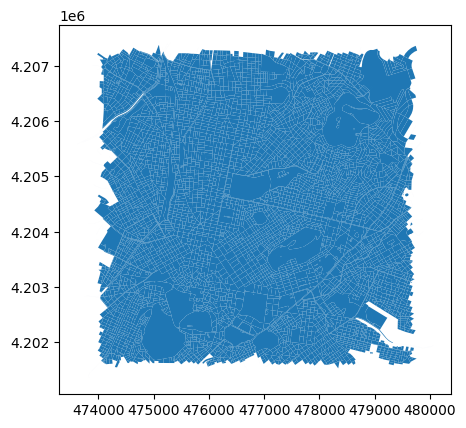

In [89]:

# Apply a small buffer to thicken the lines (try 2-3 meters)
buffered_edges = streets.buffer(0.04)

# Merge all the buffered geometries into one shape
merged = unary_union(buffered_edges)

# Polygonize the merged shape
block_polygons = list(polygonize(merged))

# Convert to GeoDataFrame
blocks = gpd.GeoDataFrame(geometry=block_polygons, crs=city.crs)

# Reproject back to lat/lon if needed
#blocks = blocks.to_crs(epsg=4326)

print(f"✅ Created {len(blocks)} polygons from buffered walk network.")

# 9️⃣ Plot
blocks.plot()

## Add Buildings

In [90]:
buildings = (
    ox.features.features_from_point(
        center_point=city.coord,
        dist=dist,
        tags={"building": True}
    )
    .query('building != "roof"')
    .to_crs(city.crs)
)
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

In [91]:
# Optional, export buildings: 

if RUN_EXPORT_buildings:
    drop_cols = [c for c in [
        "nodes", "ways", "tags", "timestamp", "version", "changeset", "uid", "user"
    ] if c in buildings.columns]
    
    buildings_out = buildings.drop(columns=drop_cols).copy()
    buildings_out["geometry"] = buildings_out.geometry.buffer(0)
    buildings_out = buildings_out.to_crs(epsg=4326)
    buildings_out.to_file(f"{city.name}_buildings.geojson", driver="GeoJSON") 

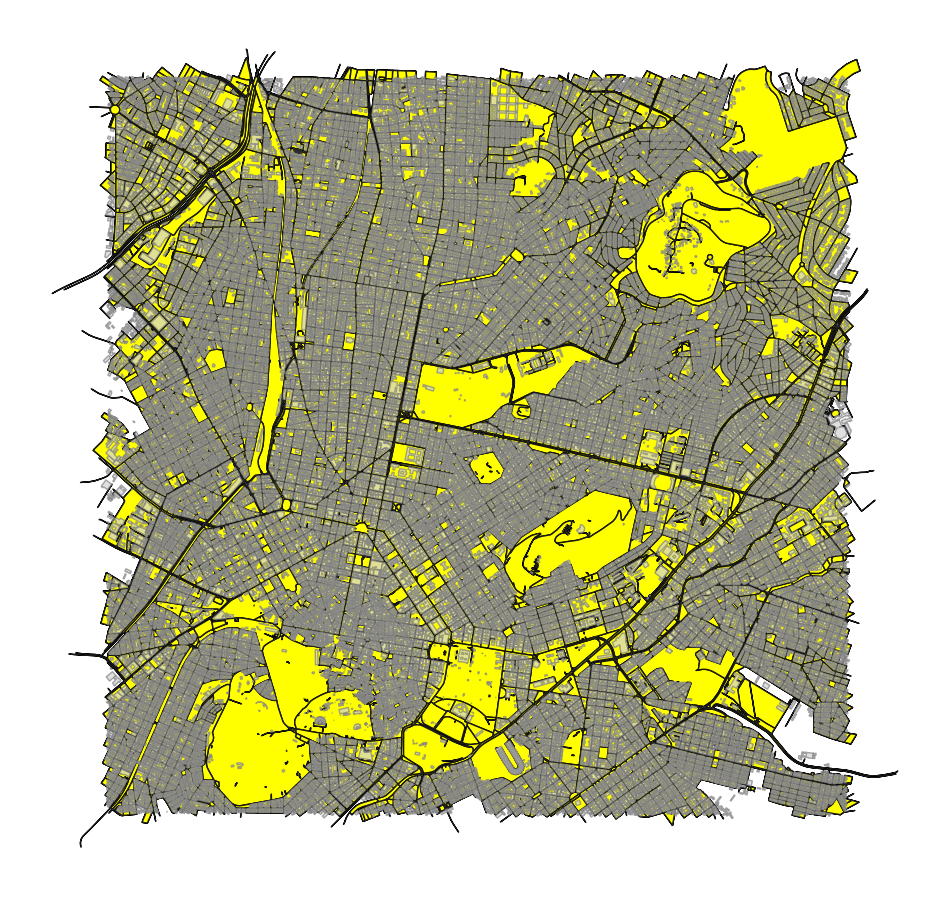

In [92]:
ax = streets.plot(figsize=(12, 12), linewidth=0.1, color='lightgrey', alpha =0.8)  # black streets
blocks.plot (ax=ax, facecolor = 'yellow', edgecolor='black')
buildings.plot(ax=ax, facecolor='lightgrey', edgecolor='grey', alpha=0.7)
ax.set_axis_off()

# 1. Main Statistics of Building footprints:

Calculate area, perimeter, centroid and Orientation of each building

Why this matters?

Blocks with low orientation variance (e.g. std_orientation < 20°) likely have consistent, regular building alignment (e.g. rowhouses or perimeter blocks).

Blocks with high orientation variance have a more organic, irregular layout (e.g. older areas, mixed-use development).

In [93]:
# get main building stats and centroid: 

buildings_with_stats = buildings.copy()
buildings_with_stats['area'] = buildings_with_stats.geometry.area
buildings_with_stats['perimeter'] = buildings_with_stats.geometry.length
buildings_with_stats['centroid'] = buildings_with_stats.geometry.centroid


In [94]:
# Get orientation of buildings

def calculate_orientation(polygon):
    mbr = polygon.minimum_rotated_rectangle
    coords = list(mbr.exterior.coords)
    if len(coords) < 2:
        return np.nan  # skip invalid shapes
    edge_vector = np.array(coords[1]) - np.array(coords[0])
    angle = np.arctan2(edge_vector[1], edge_vector[0])
    return np.degrees(angle) % 180  # 0-180 degrees

# Apply to each building
buildings_with_stats["orientation"] = buildings_with_stats.geometry.apply(calculate_orientation)

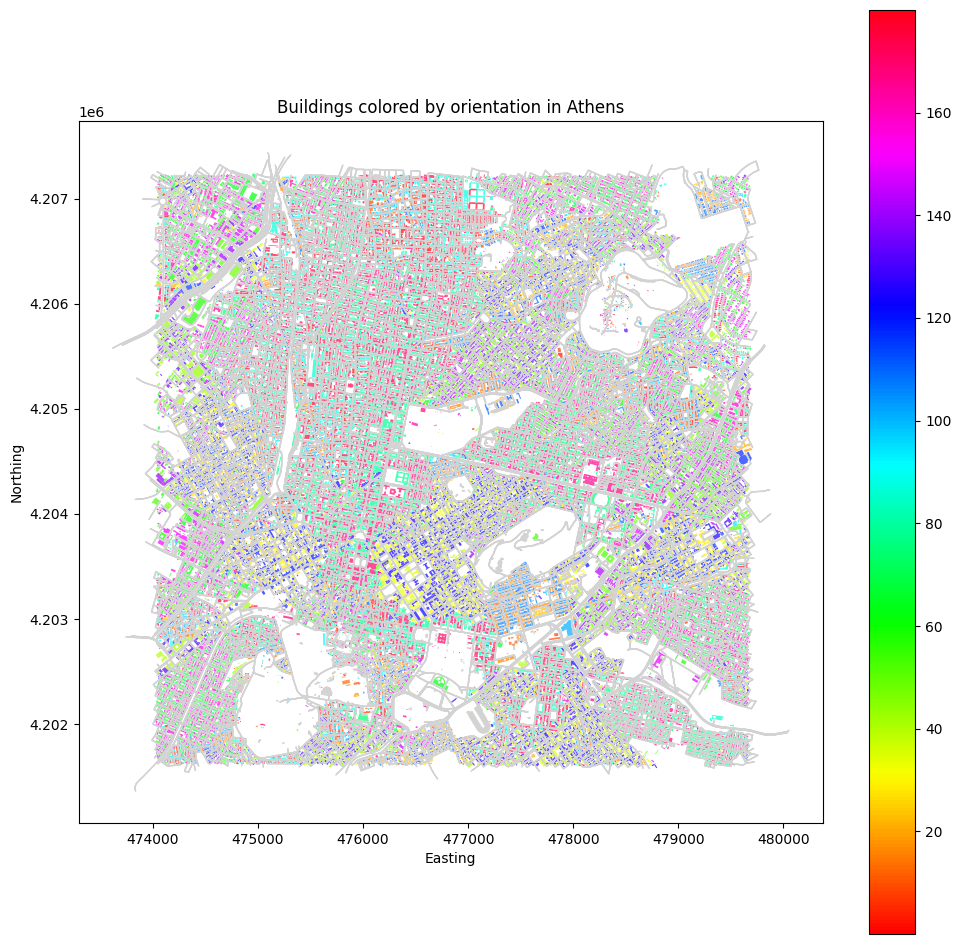

In [95]:
# Plot buildings colored by orientation
fig, ax = plt.subplots(figsize=(12, 12))

# Plot blocks boundaries in light gray
blocks.boundary.plot(ax=ax, color='lightgray', linewidth=1)

# Plot buildings colored by orientation
buildings_with_stats.plot(
    ax=ax,
    column='orientation',
    cmap='hsv',  # or 'viridis', 'plasma', etc.
    legend=True,
    alpha=0.7
)

plt.title(f"Buildings colored by orientation in {city.name}")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

# 2. Spatial Join: Join block index to building centroids: 

In [96]:
#This line Creates a new GeoDataFrame (building_centroids) where it replaces the polygon geometry to 'Point' from the centroid column for more accurate joining. 
#The original building shapes are still in the DataFrame, but they’re no longer the active geometry column.
#This is a safe and temporary way to work with centroids for spatial joins, plots, etc., without modifying the original geometry.

building_centroids = buildings_with_stats.set_geometry('centroid')
#print  (buildings_with_stats['centroid'], building_centroids['centroid'])

# Perform the spatial join with centroids for getting building no per block
building_centroids_with_blocks = gpd.sjoin(
    building_centroids,
    blocks,
    how='inner',
    predicate='within'
)

print(f"✅ Joined {len(building_centroids_with_blocks )} buildings to blocks.")

✅ Joined 58486 buildings to blocks.


# 3. Create UUIDs of Blocks and add labeling columns

In [97]:
# join building footrpings to blocks and get no of buildings stats
blocks_joined = blocks.copy()

# Group building centroids with stats by block index and calculate aggregates.
building_groups = building_centroids_with_blocks.groupby('index_right')
building_count = building_groups.size()

blocks_joined['building_count'] = building_count

# create label columns for training 


In [98]:

# Keep only blocks that contain at least one building  (!! NEEDS BETTER LOGIC TO GET ALL BLOCKS THAT DONT HAVE BUILDINGS BUT REMOVE STREETS) (EXTRACT SQUARES AND PARKS)
blocks_clean = blocks_joined[blocks_joined["building_count"] > 0].copy()

print ("Total buildings per block:",blocks_clean['building_count'])

Total buildings per block: 1        7.0
2       12.0
3        8.0
4       15.0
5       11.0
        ... 
6254     9.0
6255    13.0
6414     1.0
6573     1.0
6576     1.0
Name: building_count, Length: 5204, dtype: float64


In [99]:
# Add metadata to blocks: city name + coordinate-based absolute-ish UID

def assign_block_ids(blocks_gdf, city_name, precision=6):
    blocks = blocks_gdf.copy()

    # geometry in WGS84
    blocks["city_name"] = city_name

    # Calculate centroids in projected CRS
    centroids_projected = blocks.geometry.centroid

    # Convert centroids to WGS84 to get accurate lat lon. 
    centroids_wgs84 = gpd.GeoSeries(
        centroids_projected,
        crs=blocks.crs
    ).to_crs(epsg=4326)

    # Store coordinates
    blocks["block_lon"] = centroids_wgs84.x.round(precision)
    blocks["block_lat"] = centroids_wgs84.y.round(precision)

    # Readable coordinate-based UID
    blocks["block_uid"] = blocks.apply(
    lambda row: (
        f"{row['city_name']}_"
        f"{row['block_lat']:.{precision}f}_"
        f"{row['block_lon']:.{precision}f}"
    ),
    axis=1
    )

    return blocks

blocks_uuid = assign_block_ids(blocks_clean, city.name)


print (blocks_uuid.head())
 

                                            geometry  building_count  \
1  POLYGON ((476622.024 4207236.272, 476622.387 4...             7.0   
2  POLYGON ((476695.204 4207151.112, 476700.211 4...            12.0   
3  POLYGON ((476692.107 4207087.245, 476698.046 4...             8.0   
4  POLYGON ((476618.117 4207050.052, 476696.694 4...            15.0   
5  POLYGON ((476704.809 4207041.842, 476696.633 4...            11.0   

  city_name  block_lon  block_lat                   block_uid  
1    Athens  23.735823  38.014761  Athens_38.014761_23.735823  
2    Athens  23.735804  38.014079  Athens_38.014079_23.735804  
3    Athens  23.735770  38.013607  Athens_38.013607_23.735770  
4    Athens  23.735755  38.012985  Athens_38.012985_23.735755  
5    Athens  23.736702  38.013538  Athens_38.013538_23.736702  


# 4. Main Statistics of Blocks: 

calculate area, building area, sdrd deviation, building count, 

In [135]:
# -------------------------------------------------------
# 2. Building statistics per block
# -------------------------------------------------------

total_building_area = building_groups["area"].sum()
avg_building_area = building_groups["area"].mean()
std_building_area = building_groups["area"].std()

mean_orientation = building_groups["orientation"].mean()
std_orientation = building_groups["orientation"].std()

blocks_with_stats = blocks_uuid.copy()

blocks_with_stats["block_area"] = blocks_with_stats.geometry.area
blocks_with_stats["total_building_area"] = total_building_area
blocks_with_stats["avg_building_area"] = avg_building_area
blocks_with_stats["std_building_area"] = std_building_area

# Footprint ratio: How much of the block surface is covered by building footprints?
blocks_with_stats["footprint_ratio"] = (
    blocks_with_stats["total_building_area"] / blocks_with_stats["block_area"]
)

blocks_with_stats["footprint_percent"] = (
    blocks_with_stats["footprint_ratio"] * 100
)

# Building density: How many separate building objects are there per unit area?
blocks_with_stats["building_density_m2"] = (
    blocks_with_stats["building_count"] / blocks_with_stats["block_area"]
)
blocks_with_stats["building_density_ha"] = (
    blocks_with_stats["building_density_m2"] * 10000
)

print(blocks_with_stats["building_density_m2"].describe())
print(blocks_with_stats["building_density_ha"].describe())

blocks_with_stats["mean_orientation"] = mean_orientation
blocks_with_stats["std_orientation"] = std_orientation

# Clean infinite values before filling NaNs
blocks_with_stats = blocks_with_stats.replace([np.inf, -np.inf], np.nan)

# Typology columns for later manual / automated classification
blocks_with_stats["typology"] = ""
blocks_with_stats["sub_typology"] = ""
blocks_with_stats["typology_descr"] = ""

# Fill missing numeric values only
numeric_cols = blocks_with_stats.select_dtypes(include="number").columns
blocks_with_stats[numeric_cols] = blocks_with_stats[numeric_cols].fillna(0)

#print(blocks_with_stats.head())

count    5204.000000
mean        0.002979
std         0.022110
min         0.000006
25%         0.001981
50%         0.002682
75%         0.003375
max         1.595419
Name: building_density_m2, dtype: float64
count     5204.000000
mean        29.787207
std        221.096840
min          0.063047
25%         19.805393
50%         26.816709
75%         33.748019
max      15954.187487
Name: building_density_ha, dtype: float64


### Aspect Ratio
How stretched or elongated the block is 

aspect_ratio = max(width / height, height / width)

E.g.: A square block → width = height → aspect_ratio = 1 | A long narrow block → width = 4, height = 1 → aspect_ratio = 4

High aspect ratio → likely a fishbone or elongated grid.
Near 1 → likely perimeter block or compact grid.

In [116]:
# It works by taking the bounding box of the block, measures its width and height.
# Then gets the ratio between them — always making sure the ratio is ≥1 by flipping if needed.

# Metric functions
def aspect_ratio(polygon):
    minx, miny, maxx, maxy = polygon.bounds
    width = maxx - minx
    height = maxy - miny
    return max(width / height, height / width)

blocks_with_stats["aspect_ratio"] = blocks_with_stats.geometry.apply(aspect_ratio)

print (blocks_with_stats["aspect_ratio"].iloc[0])

1.1469195073331062


### Compactness
How "efficient" the shape is in enclosing space. It penalizes irregular or elongated shapes

compactness = 4π × area / perimeter²

It compares how much area the shape encloses vs. how much perimeter it uses.
A perfect circle has compactness = 1 (maximum efficiency). Square: compactness ~ 0.785.
Long, skinny, or jagged shapes have much lower values.

**Low compactness → likely fishbone or irregular.**
**High compactness → likely grid or perimeter.**

In [117]:
def compactness(poly):
    return 4 * np.pi * poly.area / (poly.length ** 2) if poly.length > 0 else 0

blocks_with_stats["compactness"] = blocks_with_stats.geometry.apply(compactness)
print (blocks_with_stats["compactness"].iloc[0])


0.5116254456156872


### Convexity 

How "jagged" or indented the shape is.

convexity = area / convex_hull_area

The convex hull is like stretching a rubber band around the shape.
Convexity compares how much space your shape covers vs. that outer band.

A perfectly convex shape (like a rectangle) → convexity = 1. A U-shaped or highly irregular block → convexity < 1

Low convexity → likely irregular.
Near 1 → grid or perimeter block.

In [118]:
def convexity(poly):
    hull = poly.convex_hull
    return poly.area / hull.area if hull.area > 0 else 0
blocks_with_stats["convexity"] = blocks_with_stats.geometry.apply(convexity)

print (blocks_with_stats["convexity"].iloc[0])

0.9992651932117577


# 4. Export Blocks

In [119]:
# optional for exporting blocks to geojson:


if RUN_EXPORT_blocks: 
    #  simplify with e.g. 1–3m tolerance.
    blocks_stats_built_simpl = blocks_with_stats.copy()
    blocks_stats_built_simpl["geometry"] = blocks_stats_built_simpl.geometry.simplify(2, preserve_topology=True)
    
    export_gdf = blocks_stats_built_simpl.drop(columns=[c for c in ["index_right"] if c in blocks_with_stats.columns])
    
    ##You want the CRS transform to EPSG:4326 so MapLibre/most web maps place it correctly
    export_gdf = export_gdf.to_crs(epsg=4326)
    export_gdf.to_file(f"{city.name}_blocks.geojson", driver="GeoJSON")

count      5204.000000
mean       5205.998609
std        3245.917297
min          16.487145
25%        4720.049406
50%        5476.276619
75%        5984.666863
max      219830.605237
Name: building_density_ha, dtype: float64
Colour scale min: 2373.716145745136
Colour scale max: 6626.741233271246


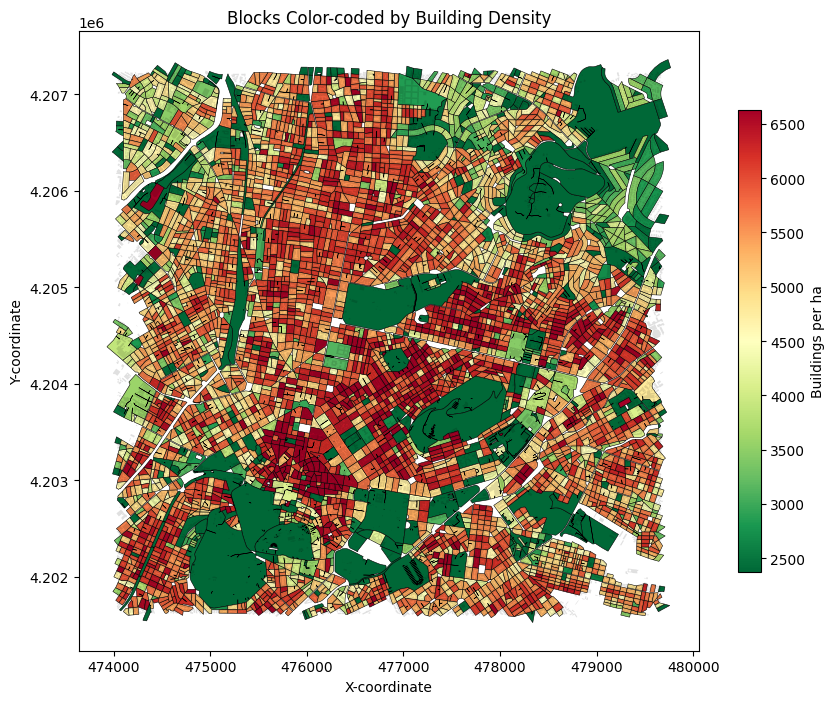

In [127]:
# for plotting purposes only

fig, ax = plt.subplots(figsize=(10, 10))

blocks_density_plot = blocks_with_stats.copy()

# Clean invalid values
blocks_density_plot["building_density_ha"] = (
    blocks_density_plot["building_density_ha"]
    .replace([np.inf, -np.inf], np.nan)
)

# Use percentiles to avoid outliers making everything green
vmin = blocks_density_plot["building_density_ha"].quantile(0.05)
vmax = blocks_density_plot["building_density_ha"].quantile(0.95)

print(blocks_density_plot["building_density_ha"].describe())
print("Colour scale min:", vmin)
print("Colour scale max:", vmax)

# Plot density
blocks_density_plot.plot(
    column="building_density_ha",
    ax=ax,
    legend=True,
    cmap="RdYlGn_r",
    vmin=vmin,
    vmax=vmax,
    linewidth=0.4,
    edgecolor="black",
    missing_kwds={
        "color": "white",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
    },
    legend_kwds={
        "label": "Buildings per ha",
        "shrink": 0.6
    }
)

# Plot buildings lightly so they don't hide the colours
buildings.plot(
    ax=ax,
    color="black",
    alpha=0.12,
    markersize=1
)

plt.title("Blocks Color-coded by Building Density")
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")

plt.show()

# Step 1: Define the Classification Rules

We’ll classify each block as one of the following:

"regular_grid", "offset" , "fishbone" , "organic" , "superblock"

In [133]:
# Classification logic
#Square: compactness ~ 0.785. cirle: 1
#A perfectly convex shape (like a rectangle) → convexity = 1. A U-shaped or highly irregular block → convexity < 1

# Density of street network --> hillier and type of area in early space syntax work in london. peponis and 

#superblocks
# internal perubility and external connectivity

#print (blocks_stats_built.head())
def classify_block(row):
    poly = row['geometry']
    asp = aspect_ratio(poly)
    comp = compactness(poly)
    conv = convexity(poly)
    dens = row["building_density_ha"]

    if row['building_count'] < 2:
        return "single plot"
    elif asp > 2 and conv > 0.5 and comp < 0.6:
        return "fishbone"
    elif asp < 2 and conv > 0.8 and dens > 3000 :
        return "perimeter"
    elif comp > 0.5:
        return "grid"
    else:
        return "other"

blocks_with_stats['type'] = blocks_with_stats.apply(classify_block, axis=1)

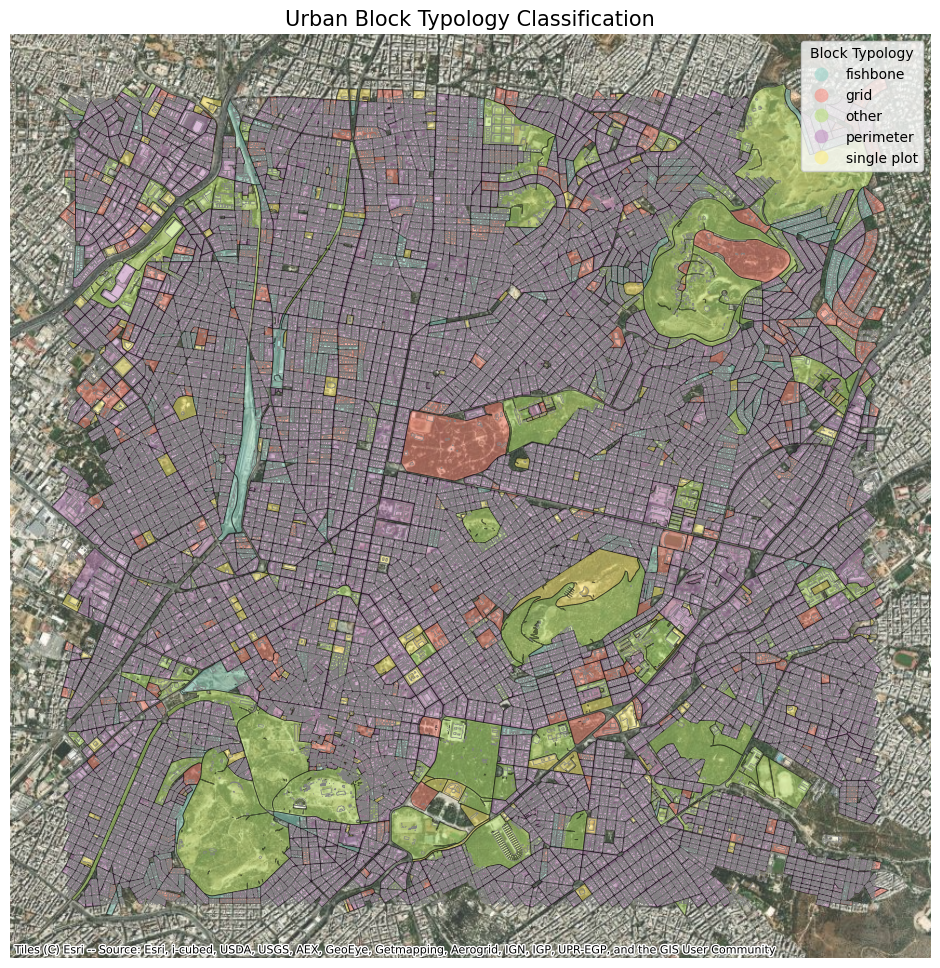

In [134]:

fig, ax = plt.subplots(figsize=(12, 12))

# Plot block typologies
blocks_with_stats.to_crs(epsg=3857).plot(
    column="type",
    ax=ax,
    legend=True,
    cmap="Set3",
    edgecolor="black",
    linewidth=0.7,
    alpha=0.5,
    categorical=True,
    legend_kwds={"title": "Block Typology"}
)

# Plot buildings in grey outline
buildings.to_crs(epsg=3857).plot(
    ax=ax,
    facecolor="none",
    edgecolor="grey",
    linewidth=0.5
)

# Add aerial basemap (Esri World Imagery)
cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, alpha=0.8)

ax.set_title("Urban Block Typology Classification", fontsize=15)
ax.set_axis_off()

plt.show()

## Mask Aerial to Block

In [110]:
# Your existing GeoDataFrame
blocks = blocks_with_stats.copy()

# Make sure it has a CRS
print(blocks.crs)

# Convert to Web Mercator for contextily
blocks_3857 = blocks.to_crs(epsg=3857)


EPSG:2100


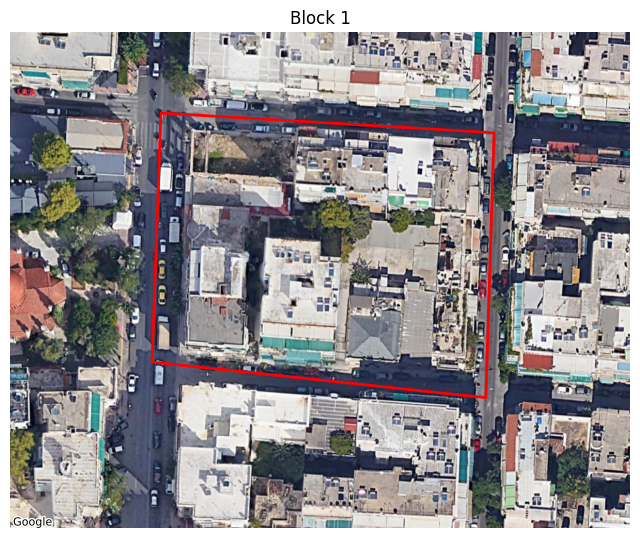

In [111]:
# Choose one block
block_id = 1
block = blocks_3857.iloc[[block_id]]

# Bounding box
minx, miny, maxx, maxy = block.total_bounds

# Small padding in metres
pad = 20
minx -= pad
miny -= pad
maxx += pad
maxy += pad

fig, ax = plt.subplots(figsize=(8, 8))

# Set extent first
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
# Add imagery at lower zoom first
#cx.add_basemap(
#    ax,
#    source= cx.providers.CartoDB.Positron,
#    zoom=17,
#    reset_extent=False
#)
cx.add_basemap(ax, source=Imagery,reset_extent=False)

# Draw the block on top
block.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2
)

ax.set_title(f"Block {block_id}")
ax.set_axis_off()
plt.show()

In [112]:
def polygon_to_clip_path(geom, ax):
    vertices = []
    codes = []

    # exterior ring only for now — simple version
    coords = np.asarray(geom.exterior.coords)

    vertices.extend(coords)
    codes.extend(
        [Path.MOVETO] +
        [Path.LINETO] * (len(coords) - 2) +
        [Path.CLOSEPOLY]
    )

    path = Path(vertices, codes)
    patch = PathPatch(path, transform=ax.transData)
    return patch

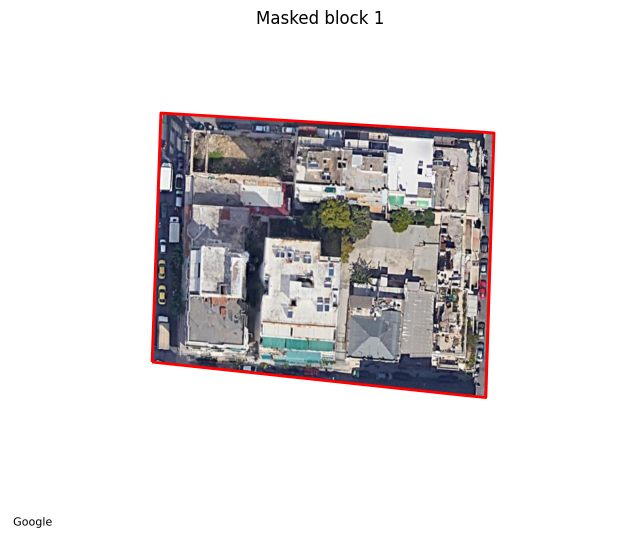

In [113]:


# Choose one block
block_id = 1
block = blocks_3857.iloc[[block_id]]

# Get the actual polygon geometry
geom = block.geometry.iloc[0]

# Bounding box
minx, miny, maxx, maxy = block.total_bounds

# Small padding in metres
pad = 20
minx -= pad
miny -= pad
maxx += pad
maxy += pad

fig, ax = plt.subplots(figsize=(8, 8))

# White background outside the block
ax.set_facecolor("white")

# Set extent first
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add imagery
cx.add_basemap(
    ax,
    source=Imagery,
    reset_extent=False
)

# Create mask from the block polygon
clip_patch = polygon_to_clip_path(geom, ax)

# Apply the mask to the basemap image
for image in ax.get_images():
    image.set_clip_path(clip_patch)

# Draw the block outline on top
block.boundary.plot(
    ax=ax,
    edgecolor="red",
    linewidth=2
)

ax.set_title(f"Masked block {block_id}")
ax.set_axis_off()
plt.show()

In [ ]:
def polygon_to_clip_path(geom, ax):
    vertices = []
    codes = []

    coords = np.asarray(geom.exterior.coords)

    vertices.extend(coords)
    codes.extend(
        [Path.MOVETO] +
        [Path.LINETO] * (len(coords) - 2) +
        [Path.CLOSEPOLY]
    )

    path = Path(vertices, codes)
    patch = PathPatch(path, transform=ax.transData)
    return patch

# choose the block ids you want to preview
block_ids = [1, 2, 3, 4]

# make sure blocks_3857 already exists
# if not, uncomment the next line:
# blocks_3857 = blocks_stats_built.to_crs(epsg=3857)

n = len(block_ids)
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))

# if there is only one block, make axes iterable
if n == 1:
    axes = [axes]

for ax, block_id in zip(axes, block_ids):
    block = blocks_3857.iloc[[block_id]]
    geom = block.geometry.iloc[0]

    minx, miny, maxx, maxy = block.total_bounds

    pad = 20
    minx -= pad
    miny -= pad
    maxx += pad
    maxy += pad

    ax.set_facecolor("white")
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    cx.add_basemap(
        ax,
        source=Imagery,
        reset_extent=False
    )

    clip_patch = polygon_to_clip_path(geom, ax)

    for image in ax.get_images():
        image.set_clip_path(clip_patch)

    block.boundary.plot(
        ax=ax,
        edgecolor="red",
        linewidth=2
    )

    ax.set_title(f"Block {block_id}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Export geolocated images of blocks

In [83]:
# EXPORT GEOLOCATED IMAGES OF BLOCKS

import os
from PIL import Image
from PIL import Image, PngImagePlugin
from rasterio.transform import from_bounds
from rasterio.features import rasterize

if RUN_EXPORT_blockimagery:

    output_folder = "block_aerial_images"
    os.makedirs(output_folder, exist_ok=True)
    
    pad = 20  # padding around each block in metres
    source = Imagery
    
    # make sure data is in Web Mercator
    blocks_3857 = blocks_3857.to_crs(epsg=3857)
    
    
    for idx, row in blocks_3857.iterrows():
        
        geom = row.geometry
        
        # use your existing unique ID if available
        block_uid = row["block_uid"]
        
        # bounding box
        minx, miny, maxx, maxy = geom.bounds
        minx -= pad
        miny -= pad
        maxx += pad
        maxy += pad
    
        try:
            # download image as array directly (no plotting)
            img, extent = cx.bounds2img(
                minx, miny, maxx, maxy,
                source=source,
                ll=False
            )
    
            # extent returned as: left, right, bottom, top
            left, right, bottom, top = extent
    
            height, width = img.shape[0], img.shape[1]
    
            # transform for rasterization
            transform = from_bounds(left, bottom, right, top, width, height)
    
            # rasterize polygon into mask
            mask = rasterize(
                [(geom, 1)],
                out_shape=(height, width),
                transform=transform,
                fill=0,
                dtype="uint8"
            )
    
            # ensure image has alpha channel
            if img.shape[2] == 3:
                alpha = np.full((height, width, 1), 255, dtype=np.uint8)
                img_rgba = np.concatenate([img, alpha], axis=2)
            else:
                img_rgba = img.copy()
    
            # apply polygon mask to alpha channel
            img_rgba[:, :, 3] = img_rgba[:, :, 3] * mask
    
            # save PNG
            out_path = os.path.join(output_folder, f"{block_uid}.png")
            Image.fromarray(img_rgba).save(out_path)
            # add metadata to PNG
            img_pil = Image.open(out_path)
            
            metadata = PngImagePlugin.PngInfo()
            metadata.add_text("city_id", str(row["city_id"]))
            metadata.add_text("block_local_id", str(row["block_local_id"]))
            metadata.add_text("block_uid", str(row["block_uid"]))
            metadata.add_text("source", "Esri.WorldImagery")
            metadata.add_text("geometry_source", "blocks_stats_built")
            metadata.add_text("crs", str(blocks_3857.crs))
            metadata.add_text("bbox_3857", f"{minx},{miny},{maxx},{maxy}")
            
            img_pil.save(out_path, pnginfo=metadata)
    
            print(f"Saved: {out_path}")
    
        except Exception as e:
            print(f"Failed for {block_uid}: {e}")
    
    
    '''
    # Save BEFORE plt.show()
    fig.savefig(
        image_path,
        dpi=200,
        facecolor=fig.get_facecolor(),
        transparent=False
    )
    
    plt.show()
    
    print("Saved:", image_path)
    '''

In [ ]:
Stop here

### Export blocks in GeoJson

In [ ]:
# Optional, export blocks (drop noisy cols, simplify, fix geom, export to EPSG:4326)
 
buildings_out["geometry"] = buildings_out.geometry.buffer(0)
buildings_out = buildings_out.to_crs(epsg=4326)
buildings_out.to_file("buildings.geojson", driver="GeoJSON")

drop_cols = [c for c in [
    "nodes", "ways", "tags", "timestamp", "version", "changeset", "uid", "user",
    "index_right"  # common join artifact
] if c in blocks_stats_built.columns]

blocks_out = blocks_stats_built.drop(columns=drop_cols).copy()

# Fix invalid geometries
blocks_out["geometry"] = blocks_out.geometry.buffer(0)

# Simplify BEFORE reproject if you're in a metric CRS (e.g. EPSG:27700); tolerance is in CRS units
# Try 1–3 (meters) if EPSG:27700
#blocks_out["geometry"] = blocks_out.geometry.simplify(2, preserve_topology=True)

# Export to web CRS
blocks_out = blocks_out.to_crs(epsg=4326)
blocks_out.to_file("blocks.geojson", driver="GeoJSON")

print("✅ Saved blocks.geojson", len(blocks_out))

### Classifying block regularity based on the standard deviation of building orientation (std_orientation).

We’ll define a simple rule:   regular if std_orientation < 20°, irregular otherwise

In [ ]:
# Classify blocks based on std_orientation
blocks_orientation["regularity"] = blocks_orientation["std_orientation"].apply(
    lambda x: "regular" if x < 20 else "irregular"
)

# Summary count
print(blocks_orientation["regularity"].value_counts())

In [ ]:
# Plot blocks colored by regularity
fig, ax = plt.subplots(figsize=(12, 12))

# Plot buildings in gray
building_with_blocks.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.5)

# Plot blocks by typology
blocks_orientation.plot(
    ax=ax,
    column="regularity",
    cmap="Set1",  # Categorical colormap (red & blue)
    legend=True,
    alpha=0.5,
    edgecolor="black"
)

plt.title(f"Block Regularity Classification in {city.name}")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

In [ ]:
def classify_typology(row):
    if row["building_count"] == 1:
        return "Single Building"
    elif row["footprint_ratio"] > 0.5 and row["building_count"] > 4:
        return "Perimeter Block"
    elif row["std_building_area"] > 100 and row["building_count"] > 5:
        return "Organic"
    elif row["std_building_area"] < 50 and row["building_count"] > 5:
        return "Regular Grid"
    elif row["building_count"] >= 3:
        return "Fishbone"
    else:
        return "Unclassified"



In [ ]:
blocks_orientation["typology"] = blocks_orientation.apply(classify_typology, axis=1)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

blocks_orientation.plot(
    column="typology",
    ax=ax,
    legend=True,
    cmap="Set3",  # You can try Set1, Set2, tab10, Pastel1, etc.
    edgecolor="black",
    linewidth=0.3,
    categorical=True,
    legend_kwds={"title": "Block Typology"}
)
# Plot buildings in black
buildings.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.5)

ax.set_title("Urban Block Typology Classification", fontsize=15)
ax.set_axis_off()

plt.show()

## NEATNET

In [ ]:
simplified = neatnet.neatify(streets, exclusion_mask=buildings.geometry)

In [ ]:
ax = streets.plot(figsize=(12, 12), linewidth=0.5)
simplified.plot(color="red", linewidth=0.5, ax=ax)
ax.set_axis_off()

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7))

streets.plot(ax=axs[0], linewidth=0.5)
simplified.plot(color="red", linewidth=0.5, ax=axs[1])
for ax in axs:
    ax.set_xlim(city_centre[0] - 500, city_centre[0] + 500)
    ax.set_ylim(city_centre[1] - 500, city_centre[1] + 500)
    ax.set_axis_off()
axs[0].set_title("original")
axs[1].set_title("simplifiied");

In [ ]:
ax = simplified.plot("_status", figsize=(12, 12), linewidth=0.5, legend=True)
ax.set_axis_off()